## Turbofan Engine RUL Prediction — Transformer & Uncertainty Quantification
 
This notebook extends the RUL forecasting pipeline with a Transformer-based sequence model and evaluates two approaches to uncertainty quantification (Quantile Regression and MC Dropout) on top of it. It reuses the FD001 sequences and preprocessing pipeline built in Notebooks 2–3, and separately evaluates Transformer transfer performance on the harder FD004 dataset.
 
**Input:** Notebook 2's processed FD001/FD004 CSVs (`data/processed/`) and the LSTM/GRU checkpoints saved in Notebook 3 (`models/LSTM_best.pt`, `models/GRU_best.pt`).

**Output:** A trained Transformer model, an FD001 model comparison (LSTM vs. GRU vs. Transformer), an FD004 Transformer evaluation, an architecture ablation, and calibration analysis for two uncertainty quantification methods.

**Objective:** Determine whether a Transformer improves on the recurrent baselines for RUL prediction, and whether reliable prediction intervals can be produced alongside the point forecast.
 

In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import mlflow
import os
import random

## Setup and Reproducibility
 
Seeds are fixed across Python, NumPy, and PyTorch (CPU and CUDA), and cuDNN is set to deterministic mode, so that results in this notebook are reproducible across reruns.

In [5]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
BASE_PATH = 'C:/Users/HP/Desktop/turbofan-rul-forecasting'
os.makedirs(f'{BASE_PATH}/data/processed', exist_ok=True)
os.makedirs(f'{BASE_PATH}/models', exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cpu


## Data Loading
 
FD001 training and validation data is loaded from the processed CSVs produced in Notebook 2. `feature_cols` excludes identifier and label columns (`unit`, `RUL`, `dataset`, `op_condition`) so only sensor/operational features are passed to the models.

In [ ]:
# --- Load Notebook 2's processed data ---
train_fd001 = pd.read_csv(f'{BASE_PATH}/data/processed/train_FD001.csv')
val_fd001 = pd.read_csv(f'{BASE_PATH}/data/processed/val_FD001.csv')
feature_cols = [c for c in train_fd001.columns if c not in ['unit', 'RUL', 'dataset', 'op_condition']]
print("Train RUL max:", train_fd001['RUL'].max(), "| Val RUL max:", val_fd001['RUL'].max())

Train RUL max: 125 | Val RUL max: 125


## Sequence Construction
 
RUL prediction depends on how an engine's sensor readings evolve over time, not on any single cycle in isolation. `create_sequences` converts each engine's per-cycle readings into fixed-length temporal windows (one sequence per starting cycle), each paired with the RUL label at the end of the window. `SequenceRegressor` wraps this in a configurable recurrent model (LSTM or GRU) so the same class can instantiate either architecture.
 
**Methodological Decision:** A fixed sequence length is used so that every training sample carries a consistent amount of temporal context, keeping batching and model input shape simple across experiments.

In [ ]:
def create_sequences(df, feature_cols, seq_length=60):
    sequences, labels = [], []
    for unit in df['unit'].unique():
        unit_data = df[df['unit'] == unit].sort_values('cycle')
        features = unit_data[feature_cols].values.astype(np.float64)
        rul = unit_data['RUL'].values.astype(np.float64)
        for i in range(len(unit_data) - seq_length + 1):
            sequences.append(features[i:i+seq_length])
            labels.append(rul[i+seq_length-1])
    return np.array(sequences), np.array(labels)

class RULDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.FloatTensor(sequences)
        self.labels = torch.FloatTensor(labels).unsqueeze(-1) # Ensure labels are (batch_size, 1)
    def __len__(self): return len(self.sequences)
    def __getitem__(self, idx): return self.sequences[idx], self.labels[idx]

class SequenceRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2, cell_type='LSTM'):
        super().__init__()
        rnn_cls = nn.LSTM if cell_type == 'LSTM' else nn.GRU
        self.rnn = rnn_cls(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Sequential(nn.Linear(hidden_size, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :]) 

## Training Loop
 
`train_model` trains a sequence model with early stopping (on validation loss), checkpoints the best-performing weights to disk, and logs metrics — including per-epoch gradient norm as a training-health diagnostic — to MLflow for experiment tracking.

In [ ]:
def train_model(model, train_loader, val_loader, epochs=50, lr=0.001, run_name='model', patience=7):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': [], 'grad_norm': []}
    best_val_loss = float('inf')
    patience_counter = 0
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({'epochs': epochs, 'lr': lr, 'hidden_size': 64, 'patience': patience})
        for epoch in range(epochs):
            model.train()
            train_loss = 0
            epoch_grad_norms = []
            for seqs, labels in train_loader:
                seqs, labels = seqs.to(device), labels.to(device)
                optimizer.zero_grad()
                loss = criterion(model(seqs), labels)
                loss.backward()
                total_norm = sum(p.grad.data.norm(2).item()**2 for p in model.parameters() if p.grad is not None) ** 0.5
                epoch_grad_norms.append(total_norm)
                optimizer.step()
                train_loss += loss.item()
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for seqs, labels in val_loader:
                    seqs, labels = seqs.to(device), labels.to(device)
                    val_loss += criterion(model(seqs), labels).item()
            train_loss /= len(train_loader)
            val_loss /= len(val_loader)
            avg_grad_norm = np.mean(epoch_grad_norms)
            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            history['grad_norm'].append(avg_grad_norm)
            mlflow.log_metrics({'train_loss': train_loss, 'val_loss': val_loss, 'grad_norm': avg_grad_norm}, step=epoch)
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save(model.state_dict(), f'{BASE_PATH}/models/{run_name}_best.pt')
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    break
    model.load_state_dict(torch.load(f'{BASE_PATH}/models/{run_name}_best.pt'))
    return model, history

## Evaluation Metrics
 
- **RMSE** is used as the primary metric: it penalizes large prediction errors more heavily, which matters for RUL since underestimating remaining life late in an engine's cycle is more consequential than small errors early on.
- **CMAPSS score** is the scoring function from the original NASA CMAPSS challenge. It is asymmetric — it penalizes late predictions (predicting a longer RUL than actual, i.e. failing to warn in time) more heavily than early ones — which better reflects the cost structure of a predictive-maintenance setting than RMSE alone.

In [ ]:
def evaluate_sequence_model(model, loader):
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for seqs, labels in loader:
            seqs = seqs.to(device)
            preds.extend(model(seqs).cpu().numpy())
            actuals.extend(labels.numpy())
    return np.array(preds), np.array(actuals)

def cmapss_score(y_true, y_pred):
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1)
    return np.sum(score)

SEQ_LENGTH = 60
X_train_seq, y_train_seq = create_sequences(train_fd001, feature_cols, seq_length=SEQ_LENGTH)
X_val_seq, y_val_seq = create_sequences(val_fd001, feature_cols, seq_length=SEQ_LENGTH)
train_loader = DataLoader(RULDataset(X_train_seq, y_train_seq), batch_size=64, shuffle=True)
val_loader = DataLoader(RULDataset(X_val_seq, y_val_seq), batch_size=64, shuffle=False)
print("Sequences ready:", X_train_seq.shape)

Sequences ready: (11841, 60, 67)


**Key Insight:** FD001 sequence construction produced 11,841 training sequences, each spanning 60 cycles across 67 features, confirming the windowing ran over the full training set at the chosen sequence length.

## Reloading Notebook 3 Baselines (No Retraining)
 
The LSTM and GRU models are reloaded directly from their Notebook 3 checkpoints rather than retrained here, so that this notebook's Transformer comparison is measured against the exact same baseline weights used in Notebook 3 — not a freshly retrained (and potentially different) version of them.

In [ ]:
# --- Reload LSTM/GRU from Notebook 3's saved checkpoints (no retraining needed) ---
lstm_model = SequenceRegressor(input_size=X_train_seq.shape[2], cell_type='LSTM').to(device)

lstm_model.load_state_dict(torch.load(f'{BASE_PATH}/models/LSTM_best.pt', map_location=device))
lstm_model.eval()

gru_model = SequenceRegressor(input_size=X_train_seq.shape[2], cell_type='GRU').to(device)

gru_model.load_state_dict(torch.load(f'{BASE_PATH}/models/GRU_best.pt', map_location=device))
gru_model.eval()

lstm_preds, lstm_actuals = evaluate_sequence_model(lstm_model, val_loader)
lstm_rmse = np.sqrt(np.mean((lstm_preds - lstm_actuals)**2))
gru_preds, gru_actuals = evaluate_sequence_model(gru_model, val_loader)
gru_rmse = np.sqrt(np.mean((gru_preds - gru_actuals)**2))

print(f"Reloaded — LSTM RMSE: {lstm_rmse:.2f}, GRU RMSE: {gru_rmse:.2f}")
print("SETUP COMPLETE")

Reloaded — LSTM RMSE: 11.17, GRU RMSE: 10.40
SETUP COMPLETE


**Key Insight:** The reloaded checkpoints reproduce the Notebook 3 baseline RMSEs exactly (LSTM 11.17, GRU 10.40), confirming these are the canonical Notebook 3 weights and not a re-trained variant — the source of a sync bug in an earlier session.

## Transformer Architecture
 
A Transformer is evaluated because self-attention lets the model weigh every cycle in the input window against every other cycle directly, rather than propagating information step-by-step as a recurrent model does. `PositionalEncoding` injects the cycle order back into the input, since attention itself is order-agnostic, using the standard sinusoidal scheme.

In [23]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

`SimpleTransformerBlock` implements one encoder block: multi-head self-attention followed by a feed-forward network, each wrapped in a residual connection and layer normalization.

In [24]:
class SimpleTransformerBlock(nn.Module):
    def __init__(self, d_model, nhead, dropout=0.2):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, d_model*4), nn.ReLU(), nn.Linear(d_model*4, d_model))
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_out, attn_weights = self.attn(x, x, x, need_weights=True, average_attn_weights=True)
        x = self.norm1(x + attn_out)
        x = self.norm2(x + self.ff(x))
        return x, attn_weights

`TransformerRegressor` stacks multiple `SimpleTransformerBlock`s on top of the positional encoding, then mean-pools across the time dimension and passes the result through a small feed-forward head to produce a single RUL prediction per sequence.

In [37]:
class TransformerRegressor(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        self.blocks = nn.ModuleList([SimpleTransformerBlock(d_model, nhead, dropout) for _ in range(num_layers)])
        self.fc = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, x, return_attention=False):
        x = self.input_proj(x)
        x = self.pos_encoding(x)
        attn_weights = None
        for block in self.blocks:
            x, attn_weights = block(x)
        out = self.fc(x.mean(dim=1)) # Removed .squeeze() to output (batch_size, 1)
        return (out, attn_weights) if return_attention else out

print("Transformer classes defined")

Transformer classes defined


## FD004 Transfer Evaluation
 
FD004 is a harder CMAPSS subset — it combines multiple operating conditions and fault modes — so evaluating the Transformer on it tests whether the architecture generalizes beyond the simpler FD001 setting.
 
**Methodological Decision:** A subsample of 80 training units and 20 validation units is used for FD004 (with units below the minimum sequence length filtered out), to keep experimentation time reasonable given the larger dataset. This means the FD004 Transformer result below is not yet directly comparable to the LSTM/GRU FD004 numbers, which were evaluated on a different sample.

In [ ]:
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEQ_LENGTH = 60

train_fd004 = pd.read_csv(f'{BASE_PATH}/data/processed/train_FD004.csv')
val_fd004 = pd.read_csv(f'{BASE_PATH}/data/processed/val_FD004.csv')
feature_cols_fd004 = [c for c in train_fd004.columns if c not in ['unit', 'RUL', 'dataset', 'op_condition']]

sample_units = train_fd004['unit'].unique()[:80]
train_fd004 = train_fd004[train_fd004['unit'].isin(sample_units)]
val_sample_units = val_fd004['unit'].unique()[:20]
val_fd004 = val_fd004[val_fd004['unit'].isin(val_sample_units)]

train_valid = train_fd004.groupby('unit').size()
train_fd004 = train_fd004[train_fd004['unit'].isin(train_valid[train_valid >= SEQ_LENGTH].index)]
val_valid = val_fd004.groupby('unit').size()
val_fd004 = val_fd004[val_fd004['unit'].isin(val_valid[val_valid >= SEQ_LENGTH].index)]

def create_sequences(df, feature_cols, seq_length=60):
    sequences, labels = [], []
    for unit in df['unit'].unique():
        unit_data = df[df['unit'] == unit].sort_values('cycle')
        features = unit_data[feature_cols].values.astype(np.float64)
        rul = unit_data['RUL'].values.astype(np.float64)
        for i in range(len(unit_data) - seq_length + 1):
            sequences.append(features[i:i+seq_length])
            labels.append(rul[i+seq_length-1])
    return np.array(sequences), np.array(labels)

X_train_seq4, y_train_seq4 = create_sequences(train_fd004, feature_cols_fd004, seq_length=SEQ_LENGTH)
X_val_seq4, y_val_seq4 = create_sequences(val_fd004, feature_cols_fd004, seq_length=SEQ_LENGTH)

class RULDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.FloatTensor(sequences)
        self.labels = torch.FloatTensor(labels).unsqueeze(-1) # Ensure labels are (batch_size, 1)
    def __len__(self): return len(self.sequences)
    def __getitem__(self, idx): return self.sequences[idx], self.labels[idx]

train_loader4 = DataLoader(RULDataset(X_train_seq4, y_train_seq4), batch_size=64, shuffle=True)
val_loader4 = DataLoader(RULDataset(X_val_seq4, y_val_seq4), batch_size=64, shuffle=False)

# Transformer classes (redefined fresh — same as Notebook 4 FD001)
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class SimpleTransformerBlock(nn.Module):
    def __init__(self, d_model, nhead, dropout=0.2):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, d_model*4), nn.ReLU(), nn.Linear(d_model*4, d_model))
        self.norm2 = nn.LayerNorm(d_model)
    def forward(self, x):
        attn_out, attn_weights = self.attn(x, x, x, need_weights=True, average_attn_weights=True)
        x = self.norm1(x + attn_out)
        x = self.norm2(x + self.ff(x))
        return x, attn_weights

class TransformerRegressor(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        self.blocks = nn.ModuleList([SimpleTransformerBlock(d_model, nhead, dropout) for _ in range(num_layers)])
        self.fc = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x, return_attention=False):
        x = self.input_proj(x)
        x = self.pos_encoding(x)
        attn_weights = None
        for block in self.blocks:
            x, attn_weights = block(x)
        out = self.fc(x.mean(dim=1)) # Removed .squeeze() to output (batch_size, 1)
        return (out, attn_weights) if return_attention else out

def cmapss_score(y_true, y_pred):
    d = y_pred - y_true
    return np.sum(np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1))

# Train with early stopping
transformer_fd004 = TransformerRegressor(input_size=X_train_seq4.shape[2]).to(device)
optimizer = torch.optim.Adam(transformer_fd004.parameters(), lr=0.0005)
criterion = nn.MSELoss()
best_val_loss, patience, patience_counter = float('inf'), 7, 0

for epoch in range(30):
    transformer_fd004.train()
    for seqs, labels in train_loader4:
        seqs, labels = seqs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(transformer_fd004(seqs), labels)
        loss.backward()
        optimizer.step()

    transformer_fd004.eval()
    val_loss = 0
    with torch.no_grad():
        for seqs, labels in val_loader4:
            seqs, labels = seqs.to(device), labels.to(device)
            val_loss += criterion(transformer_fd004(seqs), labels).item()
    val_loss /= len(val_loader4)

    if val_loss < best_val_loss:
        best_val_loss, patience_counter = val_loss, 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch} (no improvement for {patience} epochs)")
            break

# Evaluate
transformer_fd004.eval()
preds, actuals = [], []
with torch.no_grad():
    for seqs, labels in val_loader4:
        seqs = seqs.to(device)
        preds.extend(transformer_fd004(seqs).cpu().numpy())
        actuals.extend(labels.numpy())

transformer_fd004_rmse = np.sqrt(mean_squared_error(actuals, preds))
transformer_fd004_score = cmapss_score(np.array(actuals), np.array(preds))
print("FD004 Transformer RMSE:", transformer_fd004_rmse)
print("FD004 Transformer Score:", transformer_fd004_score)

Early stopping triggered at epoch 16 (no improvement for 7 epochs)
FD004 Transformer RMSE: 21.49526532756127
FD004 Transformer Score: 33803.703


**Key Insight:** On the FD004 subsample, the Transformer reached an RMSE of 21.50 (early stopping triggered at epoch 16), substantially worse than its FD001 performance — consistent with FD004 being a harder, multi-condition dataset. This number is not yet apples-to-apples with the LSTM/GRU FD004 results, since those were run on a different unit sample.

## Sanity Check
 
A freshly initialized model is trained for 2 epochs as a quick check that the training loop is functioning correctly (loss should drop sharply from a high starting point) before committing to longer ablation and final-training runs.

In [65]:
# Sanity check — 2 epochs
sanity_model = TransformerRegressor(input_size=X_train_seq.shape[2]).to(device)
optimizer = torch.optim.Adam(sanity_model.parameters(), lr=0.0005)
criterion = nn.MSELoss()
for epoch in range(2):
    sanity_model.train()
    epoch_loss = 0
    for seqs, labels in train_loader:
        seqs, labels = seqs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(sanity_model(seqs), labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {epoch_loss/len(train_loader):.2f}")

Epoch 1, Loss: 5489.64
Epoch 2, Loss: 1618.16


**Key Insight:** Loss dropped from 5489.64 to 1618.16 within two epochs, confirming the training loop, optimizer, and loss computation are working as expected before proceeding to the full ablation.

## Architecture Ablation: Attention Heads × Layers
 
We compare Transformer configurations across number of attention heads (2, 4, 8) and number of encoder layers (1, 2), using a shortened 8-epoch training run per configuration, to identify a reasonable architecture before committing to a full training run.

In [66]:
def quick_train_transformer(nhead, num_layers, epochs=8):
    model = TransformerRegressor(input_size=X_train_seq.shape[2], nhead=nhead, num_layers=num_layers).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        for seqs, labels in train_loader:
            seqs, labels = seqs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(seqs), labels)
            loss.backward()
            optimizer.step()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for seqs, labels in val_loader:
            seqs, labels = seqs.to(device), labels.to(device)
            val_loss += criterion(model(seqs), labels).item()
    return np.sqrt(val_loss / len(val_loader))

In [67]:
configs = [
    {'nhead': 2, 'num_layers': 1},
    {'nhead': 2, 'num_layers': 2},
    {'nhead': 4, 'num_layers': 1},
    {'nhead': 4, 'num_layers': 2},
    {'nhead': 8, 'num_layers': 2},
]

ablation_results = []
for cfg in configs:
    rmse = quick_train_transformer(**cfg)
    ablation_results.append({**cfg, 'RMSE': rmse})
    print(f"heads={cfg['nhead']}, layers={cfg['num_layers']}: RMSE={rmse:.2f}")

ablation_df = pd.DataFrame(ablation_results)
ablation_df

heads=2, layers=1: RMSE=10.43
heads=2, layers=2: RMSE=11.02
heads=4, layers=1: RMSE=10.00
heads=4, layers=2: RMSE=9.92
heads=8, layers=2: RMSE=11.15


,nhead,num_layers,RMSE
0,2,1,10.432209
1,2,2,11.023964
2,4,1,10.002109
3,4,2,9.924193
4,8,2,11.150071


**Key Insight:** The `nhead=4, num_layers=2` configuration achieved the lowest validation RMSE (9.92) among the tested combinations, while 8 heads degraded performance (RMSE 11.15) — likely too many attention heads for the model's hidden size. `nhead=4, num_layers=2` was therefore selected for the final Transformer.

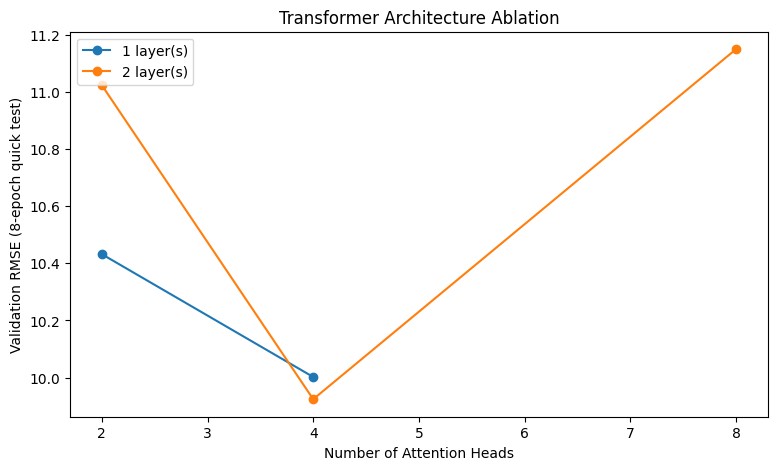

In [68]:
plt.figure(figsize=(9, 5))
for layers in ablation_df['num_layers'].unique():
    subset = ablation_df[ablation_df['num_layers'] == layers]
    plt.plot(subset['nhead'], subset['RMSE'], marker='o', label=f'{layers} layer(s)')
plt.xlabel('Number of Attention Heads'); plt.ylabel('Validation RMSE (8-epoch quick test)')
plt.title('Transformer Architecture Ablation')
plt.legend()
plt.show()

**Key Insight:** Training stopped early at epoch 9 after 7 epochs without improvement. The validation loss curve shows a sharp initial drop followed by a noisy plateau, typical of a model that converged quickly and is fluctuating near its minimum rather than still improving.

## Final Transformer Training (FD001)
 
The selected `nhead=4, num_layers=2` configuration is now trained to convergence (with early stopping) on the full FD001 training set, using the same `train_model` loop as the LSTM/GRU baselines for a fair comparison.

In [ ]:
def train_model(model, train_loader, val_loader, epochs=50, lr=0.001, run_name='model', patience=7):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': [], 'grad_norm': []}
    best_val_loss = float('inf')
    patience_counter = 0

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({'epochs': epochs, 'lr': lr, 'hidden_size': 64, 'patience': patience})

        for epoch in range(epochs):
            model.train()
            train_loss = 0
            epoch_grad_norms = []

            for seqs, labels in train_loader:
                seqs, labels = seqs.to(device), labels.to(device)
                optimizer.zero_grad()
                loss = criterion(model(seqs), labels)
                loss.backward()

                # Gradient norm — a training health diagnostic
                total_norm = sum(p.grad.data.norm(2).item()**2 for p in model.parameters() if p.grad is not None) ** 0.5
                epoch_grad_norms.append(total_norm)

                optimizer.step()
                train_loss += loss.item()

            model.eval()
            val_loss = 0
            with torch.no_grad():
                for seqs, labels in val_loader:
                    seqs, labels = seqs.to(device), labels.to(device)
                    val_loss += criterion(model(seqs), labels).item()

            train_loss /= len(train_loader)
            val_loss /= len(val_loader)
            avg_grad_norm = np.mean(epoch_grad_norms)

            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            history['grad_norm'].append(avg_grad_norm)
            mlflow.log_metrics({'train_loss': train_loss, 'val_loss': val_loss, 'grad_norm': avg_grad_norm}, step=epoch)

            # Checkpointing — always save the best version seen so far
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save(model.state_dict(), f'{BASE_PATH}/models/{run_name}_best.pt')
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered at epoch {epoch+1} (no improvement for {patience} epochs)")
                    break

    model.load_state_dict(torch.load(f'{BASE_PATH}/models/{run_name}_best.pt'))
    return model, history

final_transformer = TransformerRegressor(input_size=X_train_seq.shape[2], nhead=4, num_layers=2)  
transformer_model, transformer_history = train_model(final_transformer, train_loader, val_loader, run_name='Transformer')

Early stopping triggered at epoch 9 (no improvement for 7 epochs)


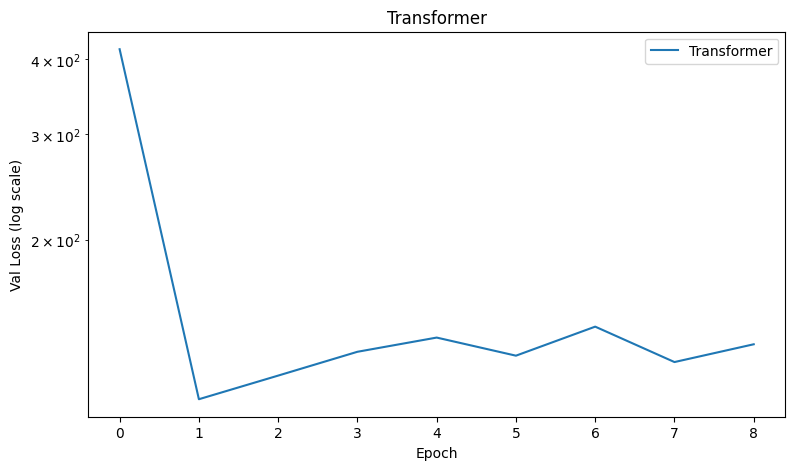

In [70]:
plt.figure(figsize=(9, 5))
plt.plot(transformer_history['val_loss'], label='Transformer')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Val Loss (log scale)')
plt.title('Transformer')
plt.legend()
plt.show()

## Model Comparison (FD001)
 
The Transformer is now evaluated with the same procedure as the LSTM and GRU baselines so the three architectures can be compared directly on validation RMSE.

In [71]:
def evaluate_sequence_model(model, loader):
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for seqs, labels in loader:
            seqs = seqs.to(device)
            preds.extend(model(seqs).cpu().numpy())
            actuals.extend(labels.numpy())
    return np.array(preds), np.array(actuals)

trans_preds, trans_actuals = evaluate_sequence_model(transformer_model, val_loader)
trans_rmse = np.sqrt(np.mean((trans_preds - trans_actuals)**2))

comparison = pd.DataFrame([
    {'Model': 'LSTM', 'RMSE': round(lstm_rmse, 2)},
    {'Model': 'GRU', 'RMSE': round(gru_rmse, 2)},
    {'Model': 'Transformer', 'RMSE': round(trans_rmse, 2)},
])
comparison

,Model,RMSE
0,LSTM,11.17
1,GRU,10.40
2,Transformer,10.50


**Key Insight:** On FD001, GRU remains the strongest model by RMSE (10.40), with the Transformer close behind (10.50) and outperforming the LSTM (11.17). The margin between GRU and the Transformer is small enough that architecture choice here is a secondary factor compared to the gap either shows over the LSTM.

## Final Results Summary — Point Prediction
 
CMAPSS scores are computed alongside RMSE for all three FD001 models and for the FD004 Transformer, to capture the asymmetric late-prediction penalty in addition to plain error magnitude.

In [72]:
lstm_cmapss = cmapss_score(lstm_actuals, lstm_preds)
gru_cmapss = cmapss_score(gru_actuals, gru_preds)
trans_cmapss = cmapss_score(trans_actuals, trans_preds)

fd001_results = [
    {'Model': 'LSTM', 'Dataset': 'FD001', 'RMSE': round(lstm_rmse, 2), 'CMAPSS Score': round(lstm_cmapss, 2)},
    {'Model': 'GRU', 'Dataset': 'FD001', 'RMSE': round(gru_rmse, 2), 'CMAPSS Score': round(gru_cmapss, 2)},
    {'Model': 'Transformer', 'Dataset': 'FD001', 'RMSE': round(trans_rmse, 2), 'CMAPSS Score': round(trans_cmapss, 2)}
]

fd004_transformer_results = [
    {'Model': 'Transformer', 'Dataset': 'FD004', 'RMSE': round(transformer_fd004_rmse, 2), 'CMAPSS Score': round(transformer_fd004_score, 2)}
]

all_results = fd001_results + fd004_transformer_results

for result in all_results:
    print(result)


{'Model': 'LSTM', 'Dataset': 'FD001', 'RMSE': np.float32(11.17), 'CMAPSS Score': np.float32(5994.02)}
{'Model': 'GRU', 'Dataset': 'FD001', 'RMSE': np.float32(10.4), 'CMAPSS Score': np.float32(5228.55)}
{'Model': 'Transformer', 'Dataset': 'FD001', 'RMSE': np.float32(10.5), 'CMAPSS Score': np.float32(4360.43)}
{'Model': 'Transformer', 'Dataset': 'FD004', 'RMSE': np.float64(21.5), 'CMAPSS Score': np.float32(33803.7)}


## Uncertainty Quantification: Quantile Regression
 
Rather than predicting a single RUL value, this model predicts the 10th, 50th, and 90th percentiles of the RUL distribution simultaneously, trained with the pinball (quantile) loss. This gives an 80% prediction interval (p10–p90) alongside the point estimate, which is useful for a maintenance decision-maker who needs to know not just the expected RUL but the range of plausible outcomes.

In [73]:
class QuantileTransformer(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        self.blocks = nn.ModuleList([SimpleTransformerBlock(d_model, nhead, dropout) for _ in range(num_layers)])
        self.fc = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(), nn.Linear(32, 3))  # [p10, p50, p90]

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoding(x)
        for block in self.blocks:
            x, _ = block(x)
        return self.fc(x.mean(dim=1))

def pinball_loss(preds, target, quantiles=[0.1, 0.5, 0.9]):
    losses = []
    for i, q in enumerate(quantiles):
        error = target - preds[:, i]
        losses.append(torch.max((q - 1) * error, q * error))
    return torch.mean(torch.stack(losses).sum(dim=0))

In [74]:
quantile_model = QuantileTransformer(input_size=X_train_seq.shape[2]).to(device)
optimizer = torch.optim.Adam(quantile_model.parameters(), lr=0.0005)

for epoch in range(30):
    quantile_model.train()
    epoch_loss = 0
    for seqs, labels in train_loader:
        seqs, labels = seqs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = pinball_loss(quantile_model(seqs), labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if epoch % 5 == 0:
        print(f"Epoch {epoch}, Pinball Loss: {epoch_loss/len(train_loader):.2f}")

Epoch 0, Pinball Loss: 94.09
Epoch 5, Pinball Loss: 29.91
Epoch 10, Pinball Loss: 29.90
Epoch 15, Pinball Loss: 29.90
Epoch 20, Pinball Loss: 29.91
Epoch 25, Pinball Loss: 29.91


**Key Insight:** Pinball loss dropped sharply in the first 5 epochs (94.09 → 29.91) and then plateaued around 29.9 for the remainder of training, indicating the quantile model converged early and further epochs provided little additional benefit.

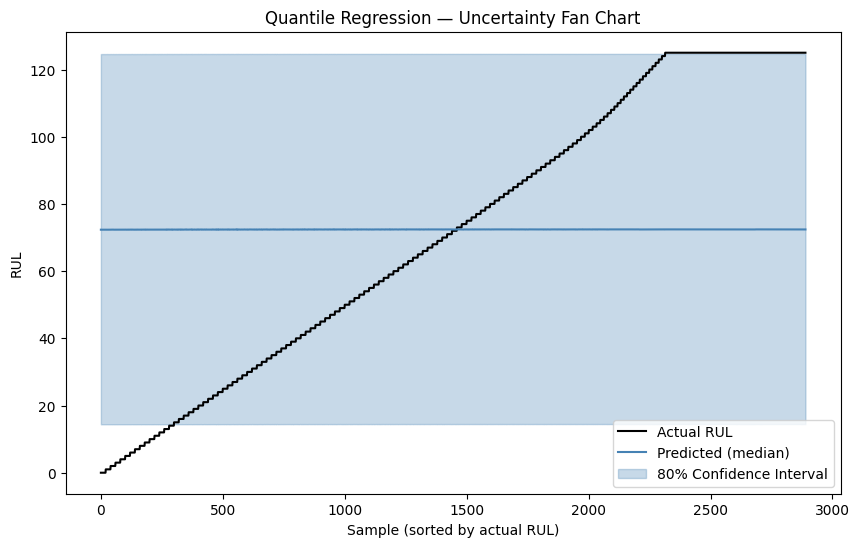

In [75]:
quantile_model.eval()
all_preds, all_actuals = [], []
with torch.no_grad():
    for seqs, labels in val_loader:
        preds = quantile_model(seqs.to(device)).cpu().numpy()
        all_preds.append(preds)
        all_actuals.extend(labels.cpu().numpy().squeeze()) # Squeeze labels to a 1D array before extending

all_preds = np.vstack(all_preds)
all_actuals = np.array(all_actuals) # Now this will be a 1D array (N,)
idx = np.argsort(all_actuals)

plt.figure(figsize=(10, 6))
plt.plot(all_actuals[idx], label='Actual RUL', color='black')
plt.plot(all_preds[idx, 1], label='Predicted (median)', color='steelblue')
plt.fill_between(range(len(idx)), all_preds[idx, 0], all_preds[idx, 2],
                  alpha=0.3, color='steelblue', label='80% Confidence Interval')
plt.xlabel('Sample (sorted by actual RUL)'); plt.ylabel('RUL')
plt.title('Quantile Regression — Uncertainty Fan Chart')
plt.legend()
plt.show()

**Key Insight:** The predicted median (blue line) is nearly flat across all samples, while actual RUL varies widely (black diagonal). This indicates the quantile model is not tracking per-sample RUL well — it produces a wide, roughly constant interval rather than intervals that narrow or shift with the true degradation trajectory.

## Uncertainty Quantification: MC Dropout
 
As an alternative to quantile regression, MC Dropout estimates uncertainty by keeping dropout active at inference time and running multiple stochastic forward passes through the trained Transformer. The spread across these passes (standard deviation) serves as an uncertainty estimate, and can be converted into a prediction interval using a normal approximation.

In [ ]:
def mc_dropout_predict(model, x, n_samples=50):
    model.train()  
    preds = []
    with torch.no_grad():
        for _ in range(n_samples):
            preds.append(model(x).cpu().numpy())
    preds = np.array(preds)
    return preds.mean(axis=0), preds.std(axis=0)

In [77]:
mc_means, mc_stds = [], []
for seqs, labels in val_loader:
    seqs = seqs.to(device)
    mean_pred, std_pred = mc_dropout_predict(transformer_model, seqs, n_samples=50)
    mc_means.extend(mean_pred)
    mc_stds.extend(std_pred)

mc_means = np.array(mc_means)
mc_stds = np.array(mc_stds)

# Convert std to an 80% interval (±1.28 std for a normal approximation)
mc_lower = mc_means - 1.28 * mc_stds
mc_upper = mc_means + 1.28 * mc_stds

In [ ]:
qr_widths = all_preds[:, 2] - all_preds[:, 0]      # p90 - p10
actual_errors = np.abs(all_actuals - all_preds[:, 1])   # |actual - median pred|

print(f"QR interval width — mean: {qr_widths.mean():.2f}")
print(f"MC Dropout std — mean: {mc_stds.mean():.2f}")
print(f"Actual |error| — mean: {actual_errors.mean():.2f}")


QR interval width — mean: 110.18
MC Dropout std — mean: 0.96
Actual |error| — mean: 35.88


**Key Insight:** The two uncertainty methods disagree sharply in scale: Quantile Regression's average interval width (110.18 cycles) is far wider than the actual average error (35.88), while MC Dropout's estimated spread (std ≈ 0.96) is far too narrow relative to that same error — the model's dropout-based uncertainty does not reflect its actual predictive error.

## Interval Coverage Check
 
Coverage measures the fraction of true RUL values that actually fall inside a method's predicted interval. For an interval designed to be an 80% interval, well-calibrated coverage should be close to 80%.

In [79]:
def coverage(y_true, lower, upper):
    return np.mean((y_true >= lower) & (y_true <= upper))

qr_coverage = coverage(all_actuals, all_preds[:, 0], all_preds[:, 2])
mc_coverage = coverage(all_actuals, mc_lower, mc_upper)

print(f"Quantile Regression 80% interval — actual coverage: {qr_coverage*100:.1f}%")
print(f"MC Dropout 80% interval — actual coverage: {mc_coverage*100:.1f}%")

Quantile Regression 80% interval — actual coverage: 69.7%
MC Dropout 80% interval — actual coverage: 1.5%


**Key Insight:** Quantile Regression's actual coverage (69.7%) is reasonably close to its nominal 80% target, but MC Dropout's actual coverage (1.5%) is drastically under the 80% target — its intervals are far too narrow to contain the true values, confirming the mismatch seen in the interval-width comparison above.

## Calibration Across Confidence Levels
 
Coverage is checked at three nominal confidence levels (50%, 80%, 95%) for MC Dropout to see whether the miscalibration observed at 80% holds consistently or is specific to that one threshold.

In [80]:
from scipy import stats

confidence_levels = [0.5, 0.8, 0.95]
z_scores = [stats.norm.ppf(0.5 + c/2) for c in confidence_levels]  # convert confidence level to z-score

reliability_data = []
for conf, z in zip(confidence_levels, z_scores):
    # MC Dropout at this confidence level
    lower = mc_means - z * mc_stds
    upper = mc_means + z * mc_stds
    mc_cov = coverage(all_actuals, lower, upper)
    reliability_data.append({'method': 'MC Dropout', 'nominal': conf, 'actual': mc_cov})

reliability_df = pd.DataFrame(reliability_data)
reliability_df

,method,nominal,actual
0,MC Dropout,0.50,0.007805
1,MC Dropout,0.80,0.014783
2,MC Dropout,0.95,0.022627


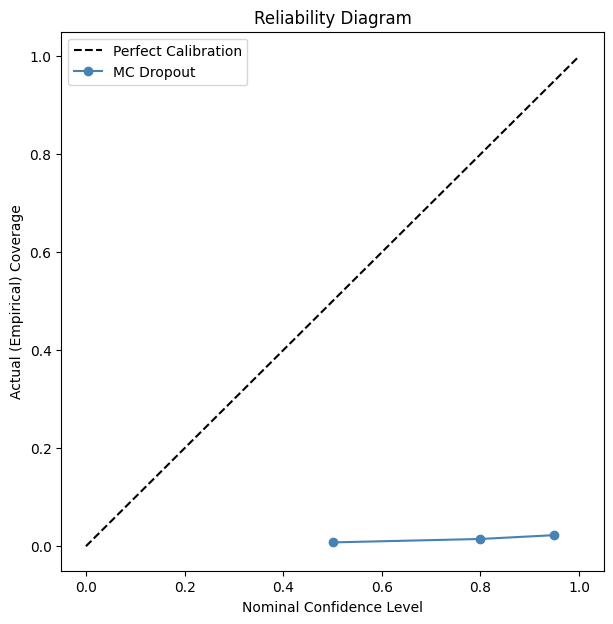

In [81]:
plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
plt.plot(reliability_df['nominal'], reliability_df['actual'], marker='o', label='MC Dropout', color='steelblue')
plt.xlabel('Nominal Confidence Level'); plt.ylabel('Actual (Empirical) Coverage')
plt.title('Reliability Diagram')
plt.legend()
plt.show()

**Key Insight:** MC Dropout's actual coverage stays far below the diagonal (perfect calibration) at every nominal confidence level tested — roughly 0.8% at the 50% level up to 2.3% at the 95% level — showing this is a systematic under-calibration of the method on this task, not an artifact of one particular threshold.

In [82]:
qr_width = np.mean(all_preds[:, 2] - all_preds[:, 0])
mc_width = np.mean(mc_upper - mc_lower)

print(f"Quantile Regression — average 80% interval width: {qr_width:.1f} cycles")
print(f"MC Dropout — average 80% interval width: {mc_width:.1f} cycles")

Quantile Regression — average 80% interval width: 110.2 cycles
MC Dropout — average 80% interval width: 2.5 cycles


**Key Insight:** Averaged across the validation set, Quantile Regression's intervals (110.2 cycles) are roughly 44× wider than MC Dropout's (2.5 cycles) for the same nominal 80% confidence level — visual confirmation that the two methods are miscalibrated in opposite directions: QR is over-wide, MC Dropout is over-narrow.

In [84]:
lstm_model.load_state_dict(torch.load(f'{BASE_PATH}/models/LSTM_best.pt', map_location=device))
lstm_model.eval()
gru_model.load_state_dict(torch.load(f'{BASE_PATH}/models/GRU_best.pt', map_location=device))
gru_model.eval()

SequenceRegressor(
  (rnn): GRU(67, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

## Conclusion
 
This notebook extended the RUL forecasting pipeline with a Transformer sequence model and two uncertainty quantification approaches. An architecture ablation selected a 4-head, 2-layer Transformer, which came close to (but did not beat) the GRU baseline on FD001 validation RMSE (10.50 vs. 10.40) while outperforming the LSTM (11.17). On the harder FD004 subset, the Transformer reached an RMSE of 21.50, though on a different unit sample than the LSTM/GRU FD004 results, so a direct comparison is still pending.
 
For uncertainty quantification, neither method was well-calibrated: Quantile Regression produced overly wide intervals (69.7% actual coverage against an 80% target), while MC Dropout produced severely overconfident, overly narrow intervals (as low as ~1.5% coverage against an 80% target) across all tested confidence levels. This instability and miscalibration is itself a notable finding for a predictive-maintenance context, where trustworthy uncertainty estimates matter as much as the point prediction.
 